In [3]:
import numpy as np
import pandas as pd

# Load the newly downloaded CSV file
file_path = r"C:\Users\HP\Downloads\countries of the world (1).csv"

# Load CSV handling comma decimals
df = pd.read_csv(file_path, decimal=',')

# Verify structure and column headers
print("Total Rows & Columns:", df.shape)
print("\nDetected Columns:")
print(df.columns.tolist())

# Preview first 3 rows
df.head(3)

Total Rows & Columns: (227, 20)

Detected Columns:
['Country', 'Region', 'Population', 'Area (sq. mi.)', 'Pop. Density (per sq. mi.)', 'Coastline (coast/area ratio)', 'Net migration', 'Infant mortality (per 1000 births)', 'GDP ($ per capita)', 'Literacy (%)', 'Phones (per 1000)', 'Arable (%)', 'Crops (%)', 'Other (%)', 'Climate', 'Birthrate', 'Deathrate', 'Agriculture', 'Industry', 'Service']


,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298


In [4]:
# Display all columns without truncation
pd.set_option('display.max_columns', None)

# View the full header and top rows
df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN


In [5]:
# Step 2: Clean column headers, string values, and numeric data types

# Strip extra whitespace from column headers
df.columns = df.columns.str.strip()

# Strip whitespace from Country and Region text fields
df['Country'] = df['Country'].astype(str).str.strip()
df['Region'] = df['Region'].astype(str).str.strip()

# Convert remaining object/text columns containing comma decimals into float numbers
for col in df.columns:
    if col not in ['Country', 'Region']:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '.').str.strip()
            df[col] = pd.to_numeric(df[col], errors='coerce')

# Check column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    object 
 1   Region                              227 non-null    object 
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    float64
 5   Coastline (coast/area ratio)        227 non-null    float64
 6   Net migration                       224 non-null    float64
 7   Infant mortality (per 1000 births)  224 non-null    float64
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    float64
 10  Phones (per 1000)                   223 non-null    float64
 11  Arable (%)                          225 non-n

In [6]:
# Step 3: Handle missing values and feature engineering

# 1. Fill missing numeric values using the median of each Region
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    df[col] = df.groupby('Region')[col].transform(lambda x: x.fillna(x.median()))

# 2. Feature Engineering: Calculate Population Share (%)
total_world_pop = df['Population'].sum()
df['Pop_Share_%'] = (df['Population'] / total_world_pop) * 100

# 3. View top 5 countries by population share
df[['Country', 'Region', 'Population', 'Pop_Share_%']].sort_values(by='Population', ascending=False).head()

,Country,Region,Population,Pop_Share_%
42,China,ASIA (EX. NEAR EAST),1313973713,20.140477
94,India,ASIA (EX. NEAR EAST),1095351995,16.789462
214,United States,NORTHERN AMERICA,298444215,4.574528
95,Indonesia,ASIA (EX. NEAR EAST),245452739,3.762279
27,Brazil,LATIN AMER. & CARIB,188078227,2.882847


C:\Users\HP\AppData\Local\Temp\ipykernel_29232\1526407292.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.values, y=region_counts.index, palette='mako')


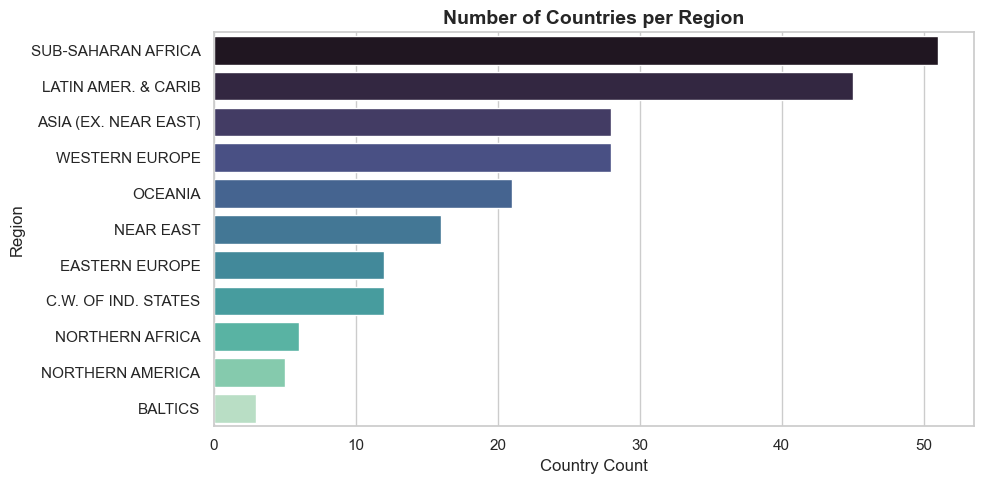

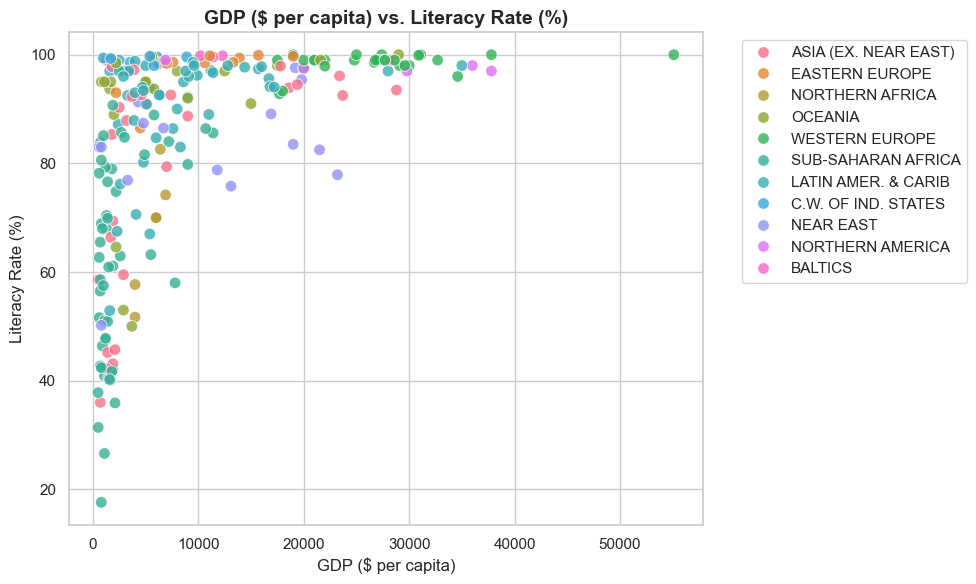

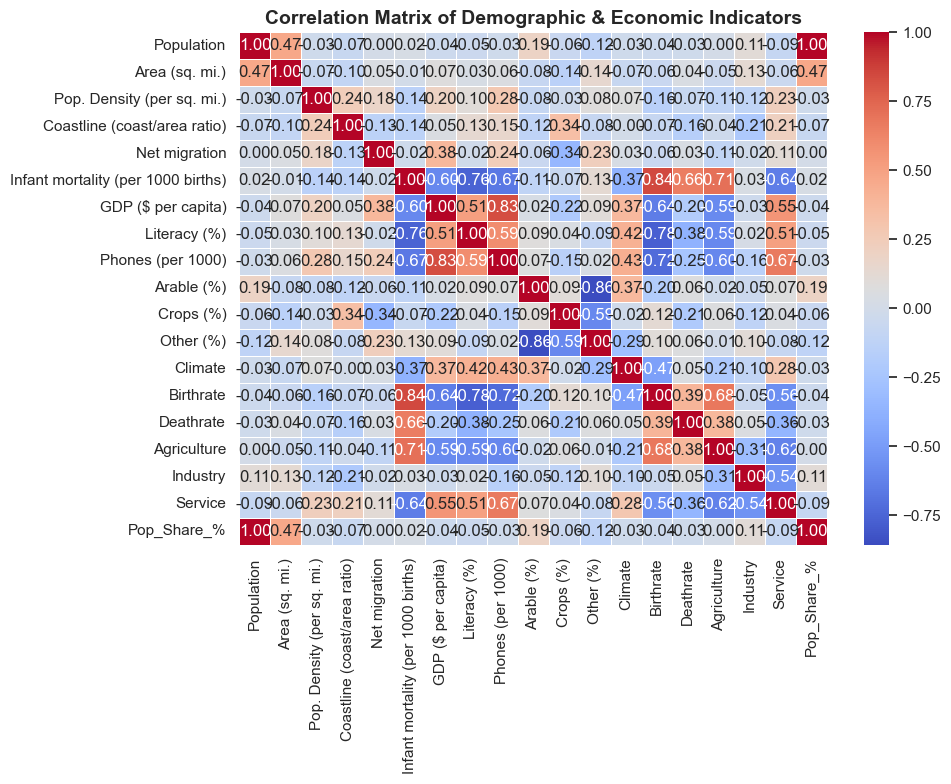

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Bar Plot: Number of Countries per Region
plt.figure(figsize=(10, 5))
region_counts = df['Region'].value_counts()
sns.barplot(x=region_counts.values, y=region_counts.index, palette='mako')
plt.title('Number of Countries per Region', fontsize=14, fontweight='bold')
plt.xlabel('Country Count')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

# 2. Scatter Plot: GDP per Capita vs. Literacy Rate
if 'GDP ($ per capita)' in df.columns and 'Literacy (%)' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df, 
        x='GDP ($ per capita)', 
        y='Literacy (%)', 
        hue='Region', 
        alpha=0.8, 
        s=70
    )
    plt.title('GDP ($ per capita) vs. Literacy Rate (%)', fontsize=14, fontweight='bold')
    plt.xlabel('GDP ($ per capita)')
    plt.ylabel('Literacy Rate (%)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# 3. Correlation Heatmap across key numeric features
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Demographic & Economic Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

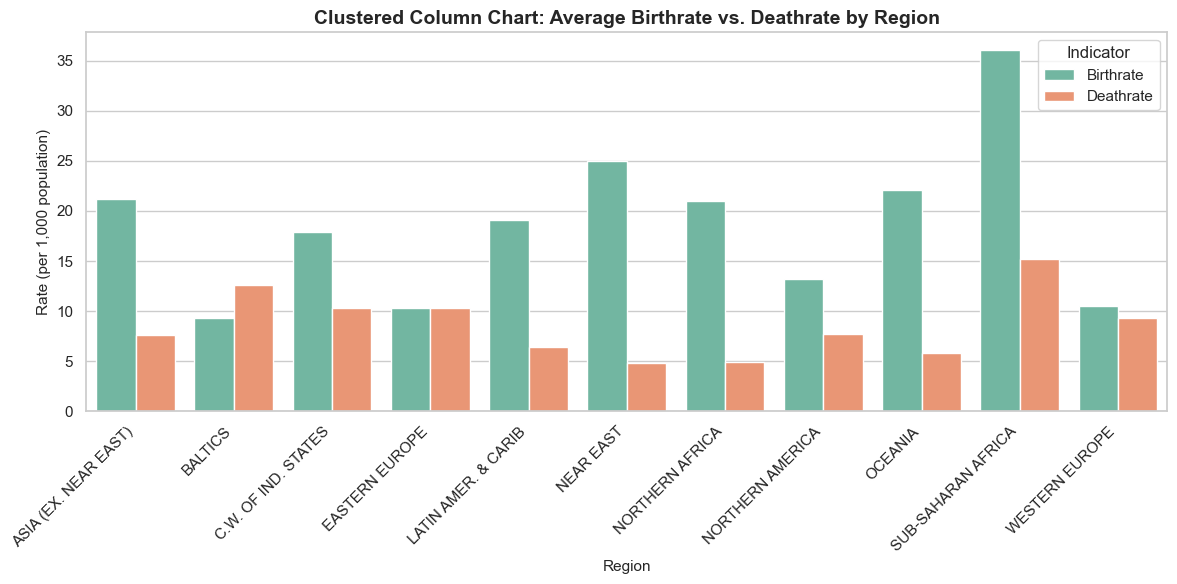

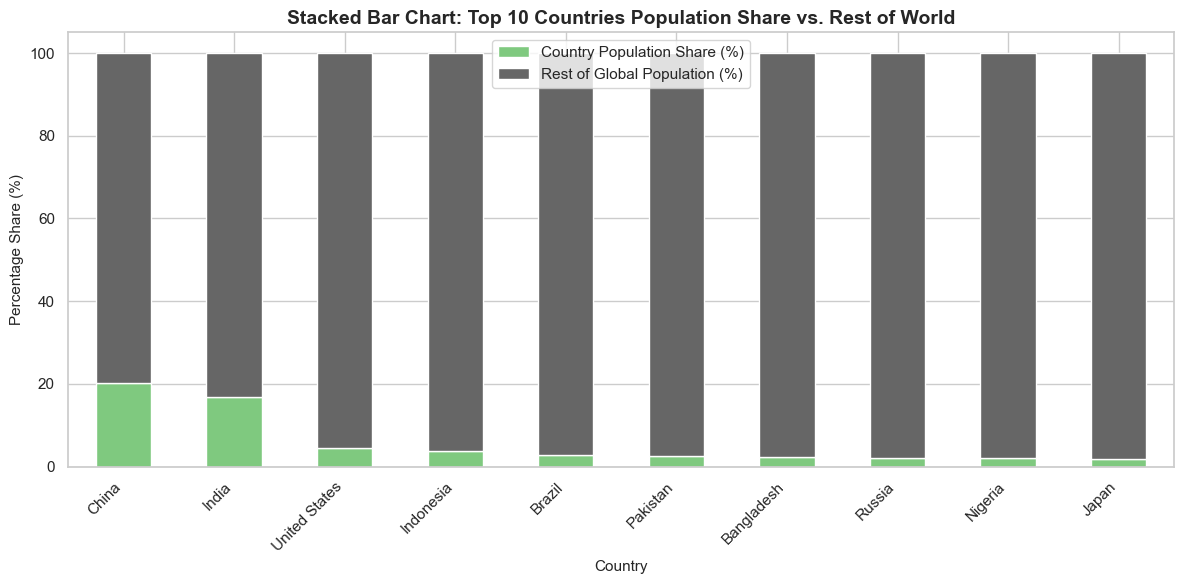

C:\Users\HP\AppData\Local\Temp\ipykernel_29232\1752182622.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Region", y="GDP ($ per capita)", palette="Set3")


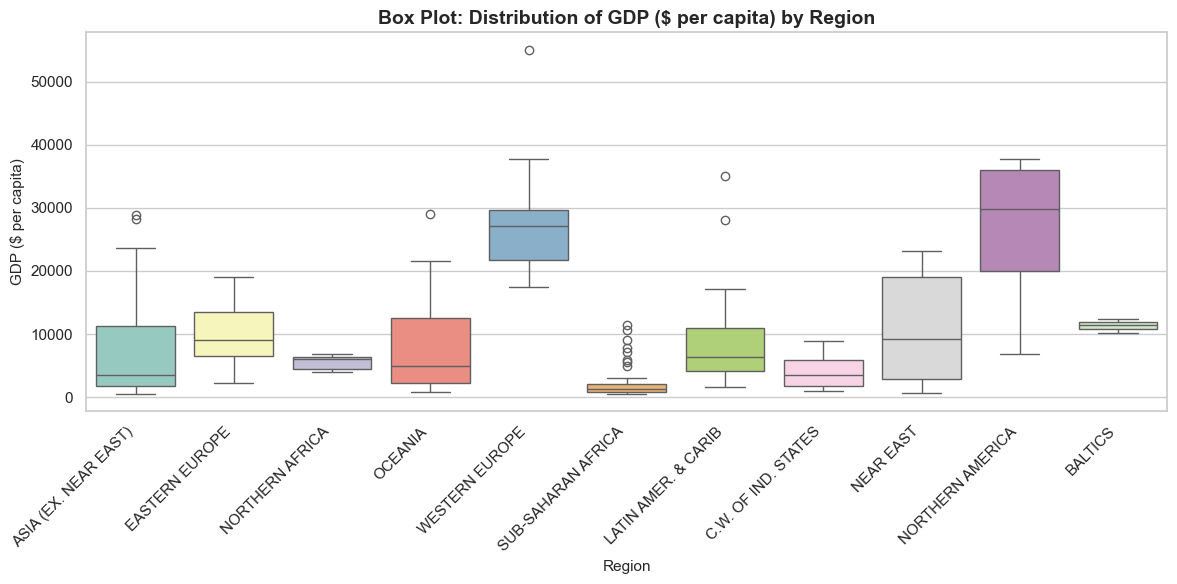

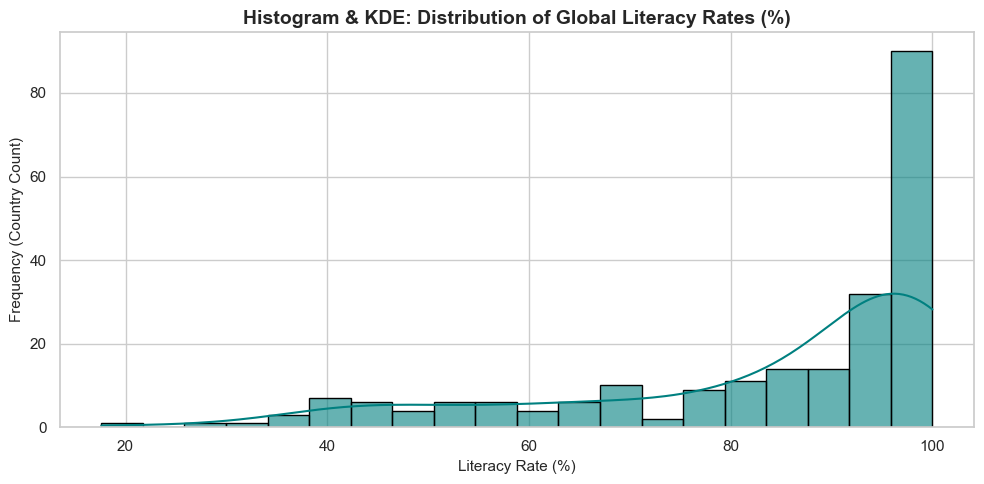

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global theme and visual defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# ---------------------------------------------------------
# 1. Clustered Column Chart (Grouped Bar Chart)
# Comparing Average Birthrate vs Deathrate across Regions
# ---------------------------------------------------------
if "Birthrate" in df.columns and "Deathrate" in df.columns:
    # Calculate regional averages
    regional_rates = (
        df.groupby("Region")[["Birthrate", "Deathrate"]].mean().reset_index()
    )

    # Reshape (melt) data for Seaborn hue plotting
    melted_rates = regional_rates.melt(
        id_vars="Region",
        value_vars=["Birthrate", "Deathrate"],
        var_name="Indicator",
        value_name="Rate per 1,000",
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=melted_rates,
        x="Region",
        y="Rate per 1,000",
        hue="Indicator",
        palette="Set2",
    )
    plt.title(
        "Clustered Column Chart: Average Birthrate vs. Deathrate by Region",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Region", fontsize=11)
    plt.ylabel("Rate (per 1,000 population)", fontsize=11)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Indicator")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 2. Stacked Bar Chart
# Top 10 Countries: Population Share vs Remaining Global Share
# ---------------------------------------------------------
top_10 = (
    df.sort_values(by="Population", ascending=False)
    .head(10)[["Country", "Pop_Share_%"]]
    .copy()
)
top_10["Rest_of_World_%"] = 100 - top_10["Pop_Share_%"]
top_10 = top_10.set_index("Country")

ax = top_10[["Pop_Share_%", "Rest_of_World_%"]].plot(
    kind="bar", stacked=True, figsize=(12, 6), colormap="Accent"
)
plt.title(
    "Stacked Bar Chart: Top 10 Countries Population Share vs. Rest of World",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Country", fontsize=11)
plt.ylabel("Percentage Share (%)", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.legend(["Country Population Share (%)", "Rest of Global Population (%)"])
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Box Plot (Distribution Analysis)
# GDP ($ per capita) Variation across Regions
# ---------------------------------------------------------
if "GDP ($ per capita)" in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="Region", y="GDP ($ per capita)", palette="Set3")
    plt.title(
        "Box Plot: Distribution of GDP ($ per capita) by Region",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Region", fontsize=11)
    plt.ylabel("GDP ($ per capita)", fontsize=11)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 4. Histogram & KDE Plot (Spread & Density)
# Distribution of Literacy Rates
# ---------------------------------------------------------
if "Literacy (%)" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(
        df["Literacy (%)"],
        kde=True,
        bins=20,
        color="teal",
        edgecolor="black",
        alpha=0.6,
    )
    plt.title(
        "Histogram & KDE: Distribution of Global Literacy Rates (%)",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Literacy Rate (%)", fontsize=11)
    plt.ylabel("Frequency (Country Count)", fontsize=11)
    plt.tight_layout()
    plt.show()